In [51]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from transformers import AutoModelForCausalLM
from tuned_lens import TunedLens

MODEL_NAME = "EleutherAI/pythia-160m-deduped"
DATA_DIR = Path("../token_evolution_data/excerpts")
N_LAYERS = 13  # layers 0-12: embedding + 12 transformer blocks

# Load model
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model.float().eval()
final_ln = model.gpt_neox.final_layer_norm

# Load TunedLens (for Part 3: translated hidden states)
tuned_lens = TunedLens.from_model_and_pretrained(model, map_location="cpu").float()
tuned_lens.eval()
torch.set_grad_enabled(False)

print("Model and TunedLens loaded.")

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1656.91it/s, Materializing param=gpt_neox.layers.11.post_attention_layernorm.weight] 


Model and TunedLens loaded.


In [52]:
excerpt_files = sorted(DATA_DIR.glob("excerpt_*.npz"))
print(f"Found {len(excerpt_files)} excerpts")

categories = ["never", "by_4", "by_0"]
cat_labels = {
    "never": "Never stabilize",
    "by_4": "Stable by layer 4",
    "by_0": "Stable by layer 0",
}

# Accumulators for average cosine similarity matrices
cos_sum_raw = {c: np.zeros((N_LAYERS, N_LAYERS)) for c in categories}
cos_sum_tl  = {c: np.zeros((N_LAYERS, N_LAYERS)) for c in categories}
token_count = {c: 0 for c in categories}


def accumulate_cos(h, acc):
    """Accumulate pairwise layer cosine similarities. h: (L, N, D), acc: (L, L)."""
    norms = np.linalg.norm(h, axis=2, keepdims=True) + 1e-10
    h_n = h / norms
    cos = np.einsum("ink,jnk->ijn", h_n, h_n)  # (L, L, N)
    acc += cos.sum(axis=2)


for fi, fpath in enumerate(excerpt_files):
    if fi % 200 == 0:
        print(f"  Processing {fi}/{len(excerpt_files)} ...")

    data = np.load(fpath, allow_pickle=True)
    hs = data["hidden_states"]          # (13, seq_len, 768)
    top_ids = data["tl_top_token_ids"]   # (13, seq_len)

    seq_len = hs.shape[1]
    end = seq_len - 1  # drop last token
    if end <= 0:
        continue

    # Writable float32 copy, dropping last token
    hs_work = np.array(hs[:, :end, :], dtype=np.float32)

    # NOTE: hidden_states[12] is already post-final-layer-norm (GPT-NeoX returns the
    # post-LN state as the last element of output_hidden_states). No need to apply
    # final_ln again.

    # ── Persistent top-1 layer (stabilization criterion) ──
    top_work = top_ids[:, :end]
    matches = top_work == top_work[-1:]
    cum = np.cumprod(matches[::-1], axis=0)[::-1]
    player = np.argmax(cum, axis=0)   # (end,)

    masks = {
        "never": player == 12,   # top-1 only matches at the final layer
        "by_4":  player <= 4,    # stabilizes at or before layer 4
        "by_0":  player == 0,    # top-1 never changes across depth
    }

    # TunedLens translated hidden states
    hs_tl_arr = np.empty_like(hs_work)
    for l in range(12):
        h = torch.tensor(hs_work[l])  # layers 0-11 are un-modified raw states
        h_t = tuned_lens.transform_hidden(h, l)
        h_ln = tuned_lens.unembed.final_norm(h_t)
        hs_tl_arr[l] = h_ln.numpy()
    # Layer 12 is already post-final-LN, so just apply final_norm for consistency
    # (this is the identity-like operation since it's already been normed by the model)
    hs_tl_arr[12] = hs_work[12]

    # Accumulate cosine similarities by category
    for cat, mask in masks.items():
        n = int(mask.sum())
        if n == 0:
            continue
        token_count[cat] += n
        accumulate_cos(hs_work[:, mask, :],    cos_sum_raw[cat])
        accumulate_cos(hs_tl_arr[:, mask, :],  cos_sum_tl[cat])

# Compute mean cosine similarity matrices
cos_mean_raw = {c: cos_sum_raw[c] / max(token_count[c], 1) for c in categories}
cos_mean_tl  = {c: cos_sum_tl[c]  / max(token_count[c], 1) for c in categories}

print("\nToken counts per category:")
for c in categories:
    print(f"  {cat_labels[c]}: {token_count[c]:,}")
print("Done.")

Found 1605 excerpts
  Processing 0/1605 ...
  Processing 200/1605 ...
  Processing 400/1605 ...
  Processing 600/1605 ...
  Processing 800/1605 ...
  Processing 1000/1605 ...
  Processing 1200/1605 ...
  Processing 1400/1605 ...
  Processing 1600/1605 ...

Token counts per category:
  Never stabilize: 105,078
  Stable by layer 4: 33,737
  Stable by layer 0: 14,353
Done.


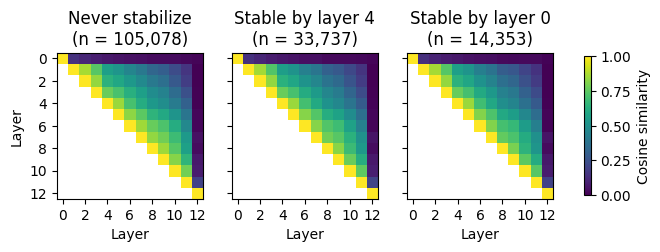

In [53]:

def plot_cossim_matrix(cos_mean_dict, categories, cat_labels, token_count):
    fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharex=True, sharey=True)
    vmin, vmax = 0, 1

    for ax, c in zip(axes, categories):
        mat = cos_mean_dict[c].copy()
        mat[np.triu_indices(N_LAYERS, k=1)] = np.nan
        im = ax.imshow(mat.T, vmin=vmin, vmax=vmax, cmap="viridis", aspect="equal")
        ax.set_title(f"{cat_labels[c]}\n(n = {token_count[c]:,})")
        ax.set_xlabel("Layer")
        if ax is axes[0]:
            ax.set_ylabel("Layer")
        ax.set_xticks(range(0, N_LAYERS, 2))
        ax.set_yticks(range(0, N_LAYERS, 2))

    fig.colorbar(im, ax=axes, shrink=0.6, label="Cosine similarity", pad=0.05)
    return fig

fig2 = plot_cossim_matrix(cos_mean_raw, categories, cat_labels, token_count)
plt.savefig("../figures/raw_hidden_cossim_new.pdf", bbox_inches="tight")

This shows the cosine similarities between TunedLens "translated hidden states"

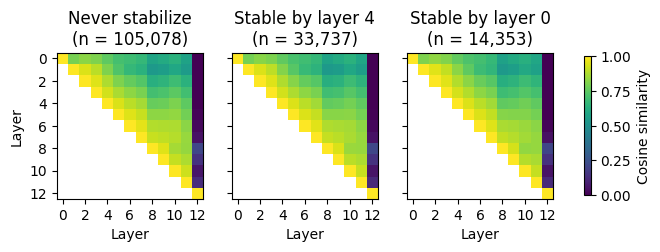

In [54]:
fig3 = plot_cossim_matrix(cos_mean_tl, categories, cat_labels, token_count)
plt.savefig("../figures/translated_hidden_cossim.pdf", bbox_inches="tight")

### Cosine similarity by model cross-entropy decile

Instead of splitting tokens by TunedLens top-1 stabilization layer, split them by the model's own cross-entropy loss. We compare the bottom decile (lowest CE — easiest tokens) vs. the top decile (highest CE — hardest tokens).

In [106]:
all_losses = []
for fi, fpath in enumerate(excerpt_files):
    data = np.load(fpath, allow_pickle=True)
    tl = data["token_losses"]  # (seq_len-1,)
    all_losses.append(tl)

all_losses = np.concatenate(all_losses)
print(f"Total tokens with losses: {len(all_losses):,}")
print(f"Loss range: [{all_losses.min():.4f}, {all_losses.max():.4f}]")

# Decile thresholds
lo_thresh = np.percentile(all_losses, 10)
hi_thresh = np.percentile(all_losses, 90)
print(f"Bottom decile (≤ {lo_thresh:.4f}): {(all_losses <= lo_thresh).sum():,} tokens")
print(f"Top decile    (≥ {hi_thresh:.4f}): {(all_losses >= hi_thresh).sum():,} tokens")

Total tokens with losses: 262,151
Loss range: [0.0000, 504.2500]
Bottom decile (≤ 0.2361): 26,219 tokens
Top decile    (≥ 8.3359): 26,275 tokens


In [ ]:
# ── Pass 2: Accumulate cosine similarity matrices for CE deciles ──
ce_categories = ["low_ce", "high_ce"]
cos_sum_ce = {c: np.zeros((N_LAYERS, N_LAYERS)) for c in ce_categories}
token_count_ce = {c: 0 for c in ce_categories}

for fi, fpath in enumerate(excerpt_files):
    if fi % 200 == 0:
        print(f"  Processing {fi}/{len(excerpt_files)} ...")

    data = np.load(fpath, allow_pickle=True)
    hs = data["hidden_states"]       # (13, seq_len, 768)
    tl = data["token_losses"]        # (seq_len-1,)

    seq_len = hs.shape[1]
    end = seq_len - 1
    if end <= 0:
        continue

    hs_work = np.array(hs[:, :end, :], dtype=np.float32)

    # Masks based on model cross-entropy
    ce_masks = {
        "low_ce":  tl <= lo_thresh,
        "high_ce": tl >= hi_thresh,
    }

    for cat, mask in ce_masks.items():
        n = int(mask.sum())
        if n == 0:
            continue
        token_count_ce[cat] += n
        accumulate_cos(hs_work[:, mask, :], cos_sum_ce[cat])

cos_mean_ce = {c: cos_sum_ce[c] / max(token_count_ce[c], 1) for c in ce_categories}

print(f"\nToken counts:  low CE = {token_count_ce['low_ce']:,},  high CE = {token_count_ce['high_ce']:,}")
print("Done.")

  Processing 0/1605 ...


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharex=True, sharey=True)

mat_lo = cos_mean_ce["low_ce"].copy()
mat_hi = cos_mean_ce["high_ce"].copy()
mat_diff = mat_lo - mat_hi  # positive = low-CE tokens more similar

# Mask upper triangle for display
tri_mask = np.triu_indices(N_LAYERS, k=1)

# Left: Low CE decile
mat_show = mat_lo.copy()
mat_show[tri_mask] = np.nan
im0 = axes[0].imshow(mat_show.T, vmin=0, vmax=1, cmap="viridis", aspect="equal")
axes[0].set_title(f"Low CE (bottom 10%)\n(n = {token_count_ce['low_ce']:,})")
axes[0].set_ylabel("Layer")

# Middle: High CE decile
mat_show = mat_hi.copy()
mat_show[tri_mask] = np.nan
im1 = axes[1].imshow(mat_show.T, vmin=0, vmax=1, cmap="viridis", aspect="equal")
axes[1].set_title(f"High CE (top 10%)\n(n = {token_count_ce['high_ce']:,})")

# Colorbar for left/middle
fig.colorbar(im1, ax=axes[:2], shrink=0.6, label="Cosine similarity", pad=0.05)

# Right: Difference (Low - High)
mat_show = mat_diff.copy()
mat_show[tri_mask] = np.nan
vlim = np.nanmax(np.abs(mat_show))
im2 = axes[2].imshow(mat_show.T, vmin=-vlim, vmax=vlim, cmap="RdBu_r", aspect="equal")
axes[2].set_title("Difference\n(Low CE − High CE)")
fig.colorbar(im2, ax=axes[2], shrink=0.6, label="Δ Cosine similarity", pad=0.05)

for ax in axes:
    ax.set_xlabel("Layer")
    ax.set_xticks(range(0, N_LAYERS, 2))
    ax.set_yticks(range(0, N_LAYERS, 2))

fig.tight_layout()
plt.savefig("../figures/raw_hidden_cossim_by_ce_decile.pdf", bbox_inches="tight")
plt.show()

In [ ]:
# ── Recompute CE-decile cosine similarities with top-1 rogue dim removed ──
# Uses sorted_dims from the rogue dimension analysis (cell 13).
# sorted_dims[0] is the single dominant rogue dimension.

rogue_dim = sorted_dims[:1]
keep_dims = np.setdiff1d(np.arange(D_MODEL), rogue_dim)

cos_sum_ce_rm = {c: np.zeros((N_LAYERS, N_LAYERS)) for c in ce_categories}
token_count_ce_rm = {c: 0 for c in ce_categories}

for fi, fpath in enumerate(excerpt_files):
    if fi % 200 == 0:
        print(f"  Recomputing CE-decile (rogue removed) {fi}/{len(excerpt_files)} ...")

    data = np.load(fpath, allow_pickle=True)
    hs = data["hidden_states"]       # (13, seq_len, 768)
    tl = data["token_losses"]        # (seq_len-1,)

    seq_len = hs.shape[1]
    end = seq_len - 1
    if end <= 0:
        continue

    hs_work = np.array(hs[:, :end, :], dtype=np.float32)

    ce_masks = {
        "low_ce":  tl <= lo_thresh,
        "high_ce": tl >= hi_thresh,
    }

    for cat, mask in ce_masks.items():
        n = int(mask.sum())
        if n == 0:
            continue
        token_count_ce_rm[cat] += n
        accumulate_cos_subset(hs_work[:, mask, :], cos_sum_ce_rm[cat], keep_dims)

cos_mean_ce_rm = {c: cos_sum_ce_rm[c] / max(token_count_ce_rm[c], 1) for c in ce_categories}

print(f"\nToken counts (sanity):  low CE = {token_count_ce_rm['low_ce']:,},  high CE = {token_count_ce_rm['high_ce']:,}")
print(f"Rogue dimension removed: dim {rogue_dim[0]}")
print("Done.")

In [ ]:
# ── 3-panel figure: CE deciles with rogue dim removed ──
fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharex=True, sharey=True)

mat_lo = cos_mean_ce_rm["low_ce"].copy()
mat_hi = cos_mean_ce_rm["high_ce"].copy()
mat_diff = mat_lo - mat_hi

tri_mask = np.triu_indices(N_LAYERS, k=1)

# Left: Low CE decile
mat_show = mat_lo.copy()
mat_show[tri_mask] = np.nan
im0 = axes[0].imshow(mat_show.T, vmin=0, vmax=1, cmap="viridis", aspect="equal")
axes[0].set_title(f"Low CE (bottom 10%)\n(n = {token_count_ce_rm['low_ce']:,})")
axes[0].set_ylabel("Layer")

# Middle: High CE decile
mat_show = mat_hi.copy()
mat_show[tri_mask] = np.nan
im1 = axes[1].imshow(mat_show.T, vmin=0, vmax=1, cmap="viridis", aspect="equal")
axes[1].set_title(f"High CE (top 10%)\n(n = {token_count_ce_rm['high_ce']:,})")

fig.colorbar(im1, ax=axes[:2], shrink=0.6, label="Cosine similarity", pad=0.05)

# Right: Difference
mat_show = mat_diff.copy()
mat_show[tri_mask] = np.nan
vlim = np.nanmax(np.abs(mat_show))
im2 = axes[2].imshow(mat_show.T, vmin=-vlim, vmax=vlim, cmap="RdBu_r", aspect="equal")
axes[2].set_title("Difference\n(Low CE − High CE)")
fig.colorbar(im2, ax=axes[2], shrink=0.6, label="Δ Cosine similarity", pad=0.05)

for ax in axes:
    ax.set_xlabel("Layer")
    ax.set_xticks(range(0, N_LAYERS, 2))
    ax.set_yticks(range(0, N_LAYERS, 2))

fig.suptitle(f"Raw hidden states, top-1 rogue dim removed (dim {rogue_dim[0]})", y=1.02)
fig.tight_layout()
plt.savefig("../figures/raw_hidden_cossim_by_ce_decile_rogue_removed.pdf", bbox_inches="tight")
plt.show()

## Sanity check: does unembedding the translated hidden states recover the expected top-1 tokens?

For a subset of excerpts, we unembed each translated hidden state (apply the unembedding matrix) and check that the argmax matches `tl_top_token_ids` from the saved data.

In [55]:
# Sanity check: unembed translated hidden states and verify top-1 match
unembed_W = tuned_lens.unembed.unembedding  # nn.Linear (vocab_size, hidden_dim)

N_CHECK = 100  # number of excerpts to check
check_files = sorted(DATA_DIR.glob("excerpt_*.npz"))[:N_CHECK]

total_tokens_checked = 0
matches_per_layer = np.zeros(N_LAYERS, dtype=np.int64)
total_per_layer = np.zeros(N_LAYERS, dtype=np.int64)

for fpath in check_files:
    data = np.load(fpath, allow_pickle=True)
    hs = data["hidden_states"]           # (13, seq_len, 768)
    top_ids = data["tl_top_token_ids"]   # (13, seq_len)
    seq_len = hs.shape[1]
    end = seq_len - 1
    if end <= 0:
        continue

    hs_f32 = np.array(hs[:, :end, :], dtype=np.float32)
    top_ref = top_ids[:, :end]  # (13, end)

    for l in range(12):
        h = torch.tensor(hs_f32[l])
        h_t = tuned_lens.transform_hidden(h, l)
        h_ln = tuned_lens.unembed.final_norm(h_t)
        logits = unembed_W(h_ln)  # (end, vocab_size)
        pred = logits.argmax(dim=-1).numpy()
        matches_per_layer[l] += (pred == top_ref[l]).sum()
        total_per_layer[l] += end

    # Final layer: hidden_states[12] is already post-final-layer-norm,
    # so unembed directly without applying final_norm again.
    h_final = torch.tensor(hs_f32[12])
    logits_final = unembed_W(h_final)
    pred_final = logits_final.argmax(dim=-1).numpy()
    matches_per_layer[12] += (pred_final == top_ref[12]).sum()
    total_per_layer[12] += end

    total_tokens_checked += end

acc = matches_per_layer / total_per_layer
print(f"Checked {N_CHECK} excerpts, {total_tokens_checked:,} tokens\n")
print("Layer | Top-1 match rate")
print("------+-----------------")
for l in range(N_LAYERS):
    print(f"  {l:2d}  |  {acc[l]:.6f}  ({matches_per_layer[l]}/{total_per_layer[l]})")

Checked 100 excerpts, 17,891 tokens

Layer | Top-1 match rate
------+-----------------
   0  |  0.996758  (17833/17891)
   1  |  0.998435  (17863/17891)
   2  |  0.998323  (17861/17891)
   3  |  0.998044  (17856/17891)
   4  |  0.998100  (17857/17891)
   5  |  0.997373  (17844/17891)
   6  |  0.997373  (17844/17891)
   7  |  0.995640  (17813/17891)
   8  |  0.985020  (17623/17891)
   9  |  0.992678  (17760/17891)
  10  |  0.996814  (17834/17891)
  11  |  0.994522  (17793/17891)
  12  |  0.890839  (15938/17891)


## Rogue dimensions analysis

We decompose the cosine similarity between layers into per-dimension contributions.
For a token with hidden states $h_i$ at layer $i$ and $h_j$ at layer $j$:

$$\cos(h_i, h_j) = \sum_d \frac{h_{i,d} \cdot h_{j,d}}{\|h_i\| \|h_j\|}$$

We compute the average contribution of each dimension to the inter-layer cosine similarity, then check whether a small number of "rogue dimensions" dominate.

In [104]:
D_MODEL = 768
N_SAMPLE = 1600  # excerpts to sample for this analysis

dimwise_sum = np.zeros((N_LAYERS, D_MODEL))  # avg contribution per dim at each layer-pair
pair_count = np.zeros(N_LAYERS)
# We compute: for each layer l, the mean per-dimension contribution to
# cos(h_l, h_{l+1}), i.e. adjacent-layer similarity.
# Also compute the global mean across ALL layer pairs.

global_dimwise = np.zeros(D_MODEL)
global_count = 0

sample_files = sorted(DATA_DIR.glob("excerpt_*.npz"))[:N_SAMPLE]

for fi, fpath in enumerate(sample_files):
    if fi % 50 == 0:
        print(f"  Rogue dim analysis: {fi}/{N_SAMPLE} ...")

    data = np.load(fpath, allow_pickle=True)
    hs = np.array(data["hidden_states"][:, :-1, :], dtype=np.float32)  # (13, end, 768)
    n_tok = hs.shape[1]
    if n_tok <= 0:
        continue

    # Compute TunedLens translated states
    hs_tl = np.empty_like(hs)
    for l in range(12):
        h_t = tuned_lens.transform_hidden(torch.tensor(hs[l]), l)
        hs_tl[l] = tuned_lens.unembed.final_norm(h_t).numpy()
    hs_tl[12] = hs[12]

    # Norms per layer per token: (13, n_tok)
    norms = np.linalg.norm(hs_tl, axis=2, keepdims=True) + 1e-10  # (13, n_tok, 1)

    # For all layer pairs (i, j) with i < j:
    for i in range(N_LAYERS):
        for j in range(i + 1, N_LAYERS):
            norm_prod = (norms[i, :, 0] * norms[j, :, 0])  # (n_tok,)
            contrib = (hs_tl[i] * hs_tl[j]) / norm_prod[:, np.newaxis]  # (n_tok, 768)
            mean_contrib = contrib.mean(axis=0)  # (768,)
            global_dimwise += mean_contrib
            global_count += 1

# Average across all layer pairs and excerpts
global_dimwise /= global_count

# Sort dimensions by average contribution
sorted_dims = np.argsort(global_dimwise)[::-1]
cumulative = np.cumsum(global_dimwise[sorted_dims])
total_abs = cumulative[-1]

print("\nTop 10 dimensions by contribution to inter-layer cos sim (translated states):")
print(f"{'Rank':>4}  {'Dim':>4}  {'Contribution':>14}  {'Cum. frac':>10}")
for rank in range(10):
    d = sorted_dims[rank]
    print(f"{rank:4d}  {d:4d}  {global_dimwise[d]:+14.6f}  {cumulative[rank]/total_abs:10.4f}")

print(f"\nTotal absolute contribution sum: {total_abs:.6f}")
print(f"Top-5 dims account for {cumulative[4]/total_abs:.1%} of total |contribution|")

  Rogue dim analysis: 0/1600 ...
  Rogue dim analysis: 50/1600 ...
  Rogue dim analysis: 100/1600 ...
  Rogue dim analysis: 150/1600 ...
  Rogue dim analysis: 200/1600 ...
  Rogue dim analysis: 250/1600 ...
  Rogue dim analysis: 300/1600 ...
  Rogue dim analysis: 350/1600 ...
  Rogue dim analysis: 400/1600 ...
  Rogue dim analysis: 450/1600 ...
  Rogue dim analysis: 500/1600 ...
  Rogue dim analysis: 550/1600 ...
  Rogue dim analysis: 600/1600 ...
  Rogue dim analysis: 650/1600 ...
  Rogue dim analysis: 700/1600 ...
  Rogue dim analysis: 750/1600 ...
  Rogue dim analysis: 800/1600 ...
  Rogue dim analysis: 850/1600 ...
  Rogue dim analysis: 900/1600 ...
  Rogue dim analysis: 950/1600 ...
  Rogue dim analysis: 1000/1600 ...
  Rogue dim analysis: 1050/1600 ...
  Rogue dim analysis: 1100/1600 ...
  Rogue dim analysis: 1150/1600 ...
  Rogue dim analysis: 1200/1600 ...
  Rogue dim analysis: 1250/1600 ...
  Rogue dim analysis: 1300/1600 ...
  Rogue dim analysis: 1350/1600 ...
  Rogue dim ana

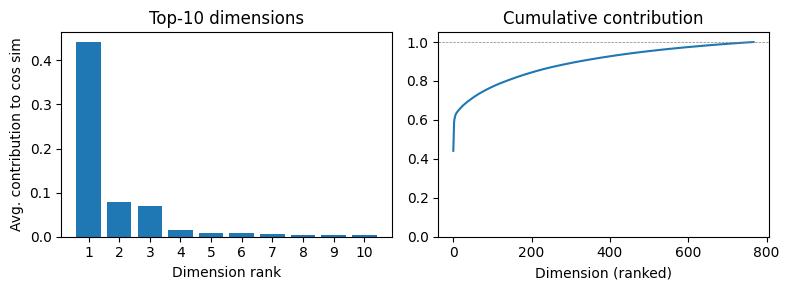

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# (a) Bar chart of top-10 dimension contributions
top_k = 10
ax = axes[0]
ax.bar(np.arange(top_k)+1, global_dimwise[sorted_dims[:top_k]] / total_abs)
ax.set_xlabel("Dimension rank")
ax.set_xticks(np.arange(1, top_k+1))
ax.set_ylabel("Avg. contribution to cos sim")
ax.set_title(f"Top-{top_k} dimensions")
ax.axhline(0, c="gray", lw=0.5, ls="--")

# (b) Cumulative contribution
ax = axes[1]
ax.plot(cumulative / total_abs)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Dimension (ranked)")
ax.set_title("Cumulative contribution")
ax.axhline(1.0, c="gray", lw=0.5, ls="--")

fig.tight_layout()
plt.savefig("../figures/rogue_dim_contributions.pdf", bbox_inches="tight")

## Recompute layer-wise cosine similarities with rogue dimensions removed

We remove the top-k rogue dimensions (k = 1, 3, 5) and recompute the translated-state cosine similarity matrices to see whether the lack of stabilization-dependence was an artifact of a few dominant dimensions.

In [ ]:
# ── Recompute cosine similarities with top-k rogue dims removed ──
K_VALUES = [1,]

# Precompute which dims to keep for each k
rogue_by_k = {k: sorted_dims[:k] for k in K_VALUES}
keep_by_k  = {k: np.setdiff1d(np.arange(D_MODEL), rogue_by_k[k]) for k in K_VALUES}

# Accumulators: cos_sum_tl_rm[k][cat] = (13, 13)
cos_sum_tl_rm = {k: {c: np.zeros((N_LAYERS, N_LAYERS)) for c in categories} for k in K_VALUES}
token_count_rm = {c: 0 for c in categories}  # same as token_count, recomputed as sanity check

def accumulate_cos_subset(h, acc, dims):
    """Like accumulate_cos but only uses dimensions in `dims`."""
    h_sub = h[:, :, dims]  # (L, N, len(dims))
    norms = np.linalg.norm(h_sub, axis=2, keepdims=True) + 1e-10
    h_n = h_sub / norms
    cos = np.einsum("ink,jnk->ijn", h_n, h_n)
    acc += cos.sum(axis=2)


for fi, fpath in enumerate(excerpt_files):
    if fi % 200 == 0:
        print(f"  Recomputing ({fi}/{len(excerpt_files)}) ...")

    data = np.load(fpath, allow_pickle=True)
    hs = data["hidden_states"]
    top_ids = data["tl_top_token_ids"]
    seq_len = hs.shape[1]
    end = seq_len - 1
    if end <= 0:
        continue

    hs_work = np.array(hs[:, :end, :], dtype=np.float32)

    # Stabilization
    top_work = top_ids[:, :end]
    matches = top_work == top_work[-1:]
    cum = np.cumprod(matches[::-1], axis=0)[::-1]
    player = np.argmax(cum, axis=0)

    masks = {
        "never": player == 12,
        "by_4":  player <= 4,
        "by_0":  player == 0,
    }

    # TunedLens translated states
    hs_tl_arr = np.empty_like(hs_work)
    for l in range(12):
        h_t = tuned_lens.transform_hidden(torch.tensor(hs_work[l]), l)
        hs_tl_arr[l] = tuned_lens.unembed.final_norm(h_t).numpy()
    hs_tl_arr[12] = hs_work[12]  # already post-LN

    for cat, mask in masks.items():
        n = int(mask.sum())
        if n == 0:
            continue
        token_count_rm[cat] += n
        h_masked = hs_tl_arr[:, mask, :]
        for k in K_VALUES:
            accumulate_cos_subset(h_masked, cos_sum_tl_rm[k][cat], keep_by_k[k])

cos_mean_tl_rm = {
    k: {c: cos_sum_tl_rm[k][c] / max(token_count_rm[c], 1) for c in categories}
    for k in K_VALUES
}

print("\nDone. Token counts (sanity check):")
for c in categories:
    print(f"  {cat_labels[c]}: {token_count_rm[c]:,}")

  Recomputing (0/1605) ...
  Recomputing (200/1605) ...
  Recomputing (400/1605) ...
  Recomputing (600/1605) ...
  Recomputing (800/1605) ...
  Recomputing (1000/1605) ...
  Recomputing (1200/1605) ...
  Recomputing (1400/1605) ...
  Recomputing (1600/1605) ...

Done. Token counts (sanity check):
  Never stabilize: 105,078
  Stable by layer 4: 33,737
  Stable by layer 0: 14,353


Removing the rogue dimensions (there is really one dimension that is "dominant") from the cosine similarity computation tends to lower the cosine similarity across depth, which makes sense. However, there is still no difference in the hidden state similarity evolution among different stabilization depths.


── Removing top-1 rogue dimension(s): dims [np.int64(429)] ──

── Removing top-3 rogue dimension(s): dims [np.int64(429), np.int64(684), np.int64(393)] ──

── Removing top-5 rogue dimension(s): dims [np.int64(429), np.int64(684), np.int64(393), np.int64(737), np.int64(177)] ──


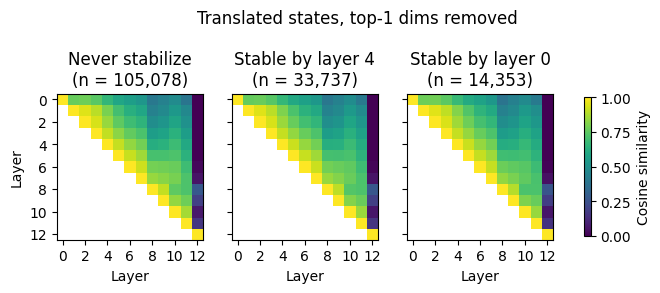

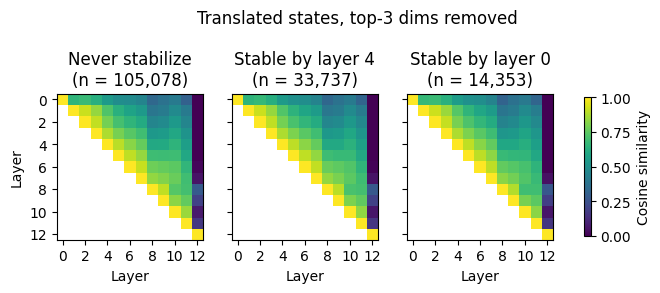

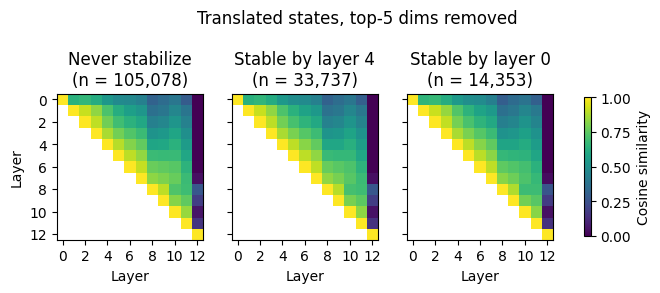

In [103]:
for k in K_VALUES:
    print(f"\n── Removing top-{k} rogue dimension(s): dims {list(rogue_by_k[k])} ──")
    fig = plot_cossim_matrix(cos_mean_tl_rm[k], categories, cat_labels, token_count_rm)
    fig.suptitle(f"Translated states, top-{k} dims removed", y=1.02)
    plt.savefig(f"../figures/translated_hidden_cossim_top-{k}_rogue_removed.pdf", bbox_inches="tight")

---
## Resolving the puzzle: why doesn't hidden-state cosine similarity differ by stabilization category?

**Observation:** Translated hidden state cosine similarity matrices look identical for "never stabilize," "stable by layer 4," and "stable by layer 0" tokens. Yet top-1 TunedLens predictions behave very differently across these groups.

**Key insight:** Top-1 prediction stability depends on $\arg\max_v \, w_v^\top h_l$, i.e., the ranking of 1D projections of $h$ onto each unembedding row $w_v$. Cosine similarity measures overall direction in the full 768-dim space. These are fundamentally different operations — changes in a tiny subspace can flip the argmax without affecting cosine similarity, and conversely, large overall direction changes can preserve the argmax if the margin is large.

### Hypotheses

**H1 — Logit margin:** Early-stabilizing tokens have large logit margins (gap between top-1 and top-2 logits) at every layer, making predictions robust to hidden state changes. Never-stabilizing tokens have small margins, so even similar-magnitude direction changes flip the ranking.

**H2 — Vocab-space cosine similarity diverges:** If we compute cosine similarity in the logit/vocab space ($\cos(Wh_i, Wh_j)$) instead of hidden space ($\cos(h_i, h_j)$), the categories should separate. The unembedding projects onto the task-relevant subspace.

**H3 — Decision-relevant subspace:** The direction change $\Delta h = h_{l+1} - h_l$ has similar magnitude for all tokens, but for never-stabilizing tokens it projects more strongly onto the "decision boundary" (direction between top-1 and top-2 unembedding rows).

**H4 — Token characteristics:** Early-stabilizing tokens are simply "easy" tokens (function words, high-frequency, predictable context) with lower cross-entropy, not tokens whose hidden states evolve differently.

### H4 — Token-level statistics by stabilization category

Before testing mechanistic hypotheses, let's understand *what kinds of tokens* fall into each category: their identities, frequencies, and losses.

In [84]:
# ── H4: Aggregate token statistics by stabilization category ──
from collections import Counter
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Accumulators
loss_by_cat = {c: [] for c in categories}
entropy_by_cat = {c: [] for c in categories}       # final-layer TunedLens entropy
token_id_counts = {c: Counter() for c in categories}
token_str_counts = {c: Counter() for c in categories}

for fi, fpath in enumerate(excerpt_files):
    if fi % 200 == 0:
        print(f"  Token stats: {fi}/{len(excerpt_files)} ...")

    data = np.load(fpath, allow_pickle=True)
    top_ids = data["tl_top_token_ids"]    # (13, seq_len)
    token_losses = data["token_losses"]   # (seq_len-1,)
    token_strings = data["token_strings"] # (seq_len,)
    input_ids = data["input_ids"]         # (seq_len,)
    tl_entropy = data["tl_entropy"]       # (13, seq_len)

    seq_len = top_ids.shape[1]
    end = seq_len - 1
    if end <= 0:
        continue

    # Stabilization (same as cell 2)
    top_work = top_ids[:, :end]
    matches = top_work == top_work[-1:]
    cum_match = np.cumprod(matches[::-1], axis=0)[::-1]
    player = np.argmax(cum_match, axis=0)

    masks = {
        "never": player == 12,
        "by_4":  player <= 4,
        "by_0":  player == 0,
    }

    for cat, mask in masks.items():
        idx = np.where(mask)[0]
        if len(idx) == 0:
            continue
        loss_by_cat[cat].extend(token_losses[idx].tolist())
        # Final-layer entropy for each token (layer 12)
        entropy_by_cat[cat].extend(tl_entropy[12, idx].tolist())
        for i in idx:
            # Token at position i+1 is the *target* token (what we're predicting)
            # Token at position i is the *context* token whose hidden state we're analyzing
            tid = int(input_ids[i + 1])  # target token
            token_id_counts[cat][tid] += 1
            token_str_counts[cat][token_strings[i + 1]] += 1

# ── Summary statistics ──
print("\n" + "="*70)
print("TOKEN STATISTICS BY STABILIZATION CATEGORY")
print("="*70)

for c in categories:
    losses = np.array(loss_by_cat[c])
    entropies = np.array(entropy_by_cat[c])
    n = len(losses)
    print(f"\n── {cat_labels[c]} (n = {n:,}) ──")
    print(f"  Cross-entropy loss:  mean={losses.mean():.3f}, median={np.median(losses):.3f}, "
          f"std={losses.std():.3f}")
    print(f"  Final-layer entropy: mean={entropies.mean():.3f}, median={np.median(entropies):.3f}")
    print(f"  Top-10 target tokens:")
    for tok_id, count in token_id_counts[c].most_common(10):
        tok_str = tokenizer.decode([tok_id])
        pct = count / n * 100
        print(f"    {repr(tok_str):>15s} (id={tok_id:5d}): {count:6d} ({pct:.1f}%)")

print("\nDone.")

  Token stats: 0/1605 ...
  Token stats: 200/1605 ...
  Token stats: 400/1605 ...
  Token stats: 600/1605 ...
  Token stats: 800/1605 ...
  Token stats: 1000/1605 ...
  Token stats: 1200/1605 ...
  Token stats: 1400/1605 ...
  Token stats: 1600/1605 ...

TOKEN STATISTICS BY STABILIZATION CATEGORY

── Never stabilize (n = 105,078) ──
  Cross-entropy loss:  mean=4.537, median=4.047, std=2.942
  Final-layer entropy: mean=4.695, median=4.824
  Top-10 target tokens:
               ' .' (id=  964):   3225 (3.1%)
               ' ,' (id= 1157):   3185 (3.0%)
             ' the' (id=  253):   3033 (2.9%)
             ' and' (id=  285):   1882 (1.8%)
              ' in' (id=  275):   1455 (1.4%)
              ' of' (id=  273):   1266 (1.2%)
              ' to' (id=  281):   1141 (1.1%)
               ' @' (id= 1214):   1129 (1.1%)
               ' "' (id=  346):    927 (0.9%)
               ' a' (id=  247):    897 (0.9%)

── Stable by layer 4 (n = 33,737) ──
  Cross-entropy loss:  mean=3.152, m

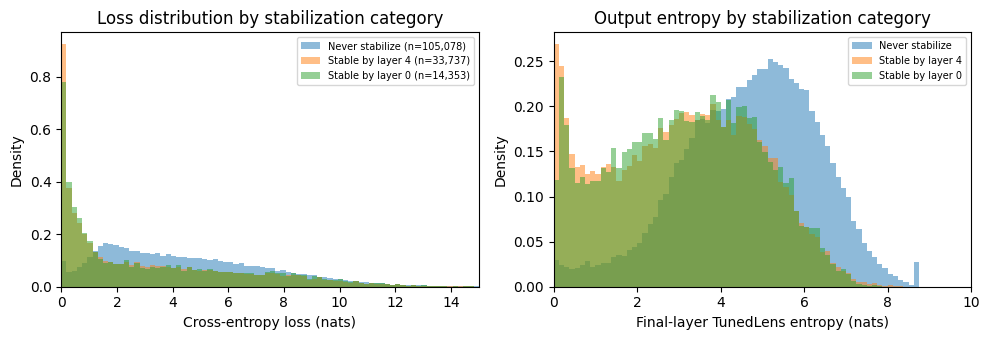

In [85]:
# ── H4 Visualization: Loss & entropy distributions by category ──
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

# (a) Cross-entropy loss distributions
ax = axes[0]
for c in categories:
    losses = np.array(loss_by_cat[c])
    ax.hist(losses, bins=80, range=(0, 15), density=True, alpha=0.5,
            label=f"{cat_labels[c]} (n={len(losses):,})")
ax.set_xlabel("Cross-entropy loss (nats)")
ax.set_ylabel("Density")
ax.set_title("Loss distribution by stabilization category")
ax.legend(fontsize=7)
ax.set_xlim(0, 15)

# (b) Final-layer entropy distributions
ax = axes[1]
for c in categories:
    ent = np.array(entropy_by_cat[c])
    ax.hist(ent, bins=80, range=(0, 10), density=True, alpha=0.5,
            label=f"{cat_labels[c]}")
ax.set_xlabel("Final-layer TunedLens entropy (nats)")
ax.set_ylabel("Density")
ax.set_title("Output entropy by stabilization category")
ax.legend(fontsize=7)
ax.set_xlim(0, 10)

fig.tight_layout()
plt.savefig("../figures/token_stats_by_stabilization.pdf", bbox_inches="tight")
plt.show()

### H1 — Logit margin hypothesis

If the argmax is robust (large gap between top-1 and top-2 logits), the prediction can remain stable even as the hidden state direction changes. We compute the logit margin at each layer for each category.

The key quantity is the **logit margin**: $m_l = z_{l,(1)} - z_{l,(2)}$, where $z_{l,(1)}$ and $z_{l,(2)}$ are the largest and second-largest logits from the TunedLens at layer $l$.

If H1 is correct, early-stabilizing tokens should have consistently large margins, while never-stabilizing tokens should have small margins — explaining why prediction stability differs even though hidden-state cosine similarity does not.

In [86]:
# ── H1: Logit margin analysis by stabilization category ──
# For each token, compute logit margin (top1 - top2) at each layer via TunedLens.
# This requires computing full logits, which is expensive. We use a subset.

N_MARGIN = 400  # excerpts to analyze
margin_files = sorted(DATA_DIR.glob("excerpt_*.npz"))[:N_MARGIN]

# Accumulators: margin_sum[cat][layer], margin_count[cat]
margin_sum = {c: np.zeros(N_LAYERS) for c in categories}
margin_count = {c: np.zeros(N_LAYERS) for c in categories}

# Also track norms of translated hidden states
norm_sum = {c: np.zeros(N_LAYERS) for c in categories}
norm_count = {c: np.zeros(N_LAYERS) for c in categories}

for fi, fpath in enumerate(margin_files):
    if fi % 100 == 0:
        print(f"  Logit margin: {fi}/{N_MARGIN} ...")

    data = np.load(fpath, allow_pickle=True)
    hs = data["hidden_states"]
    top_ids = data["tl_top_token_ids"]
    seq_len = hs.shape[1]
    end = seq_len - 1
    if end <= 0:
        continue

    hs_f32 = np.array(hs[:, :end, :], dtype=np.float32)

    # Stabilization
    top_work = top_ids[:, :end]
    matches = top_work == top_work[-1:]
    cum_match = np.cumprod(matches[::-1], axis=0)[::-1]
    player = np.argmax(cum_match, axis=0)

    masks = {
        "never": player == 12,
        "by_4":  player <= 4,
        "by_0":  player == 0,
    }

    # Compute translated hidden states and logits at each layer
    for l in range(N_LAYERS):
        h = torch.tensor(hs_f32[l])
        if l < 12:
            h_t = tuned_lens.transform_hidden(h, l)
            h_ln = tuned_lens.unembed.final_norm(h_t)
        else:
            h_ln = h  # layer 12 is already post-LN

        # Compute logits
        logits = unembed_W(h_ln)  # (end, vocab_size)
        # Top-2 logits
        top2_vals, _ = torch.topk(logits, k=2, dim=-1)  # (end, 2)
        margins = (top2_vals[:, 0] - top2_vals[:, 1]).numpy()  # (end,)

        # Norms
        h_norms = np.linalg.norm(h_ln.numpy(), axis=1)  # (end,)

        for cat, mask in masks.items():
            n = int(mask.sum())
            if n == 0:
                continue
            margin_sum[cat][l] += margins[mask].sum()
            margin_count[cat][l] += n
            norm_sum[cat][l] += h_norms[mask].sum()
            norm_count[cat][l] += n

# Compute means
margin_mean = {c: margin_sum[c] / np.maximum(margin_count[c], 1) for c in categories}
norm_mean = {c: norm_sum[c] / np.maximum(norm_count[c], 1) for c in categories}

print("\nLogit margin (top1 - top2) by layer and category:")
print(f"{'Layer':>5}", end="")
for c in categories:
    print(f"  {cat_labels[c]:>20s}", end="")
print()
for l in range(N_LAYERS):
    print(f"  {l:3d}", end="")
    for c in categories:
        print(f"  {margin_mean[c][l]:20.3f}", end="")
    print()

print(f"\nTokens per category: ", {cat_labels[c]: int(margin_count[c][0]) for c in categories})

  Logit margin: 0/400 ...
  Logit margin: 100/400 ...
  Logit margin: 200/400 ...
  Logit margin: 300/400 ...

Logit margin (top1 - top2) by layer and category:
Layer       Never stabilize     Stable by layer 4     Stable by layer 0
    0                 0.580                 0.729                 1.022
    1                 0.529                 0.858                 1.137
    2                 0.570                 0.963                 1.282
    3                 0.593                 1.170                 1.503
    4                 0.645                 1.405                 1.686
    5                 0.662                 1.654                 1.722
    6                 0.633                 1.708                 1.750
    7                 0.671                 1.885                 1.896
    8                 0.703                 2.037                 2.019
    9                 0.697                 2.117                 2.133
   10                 0.703                 2.3

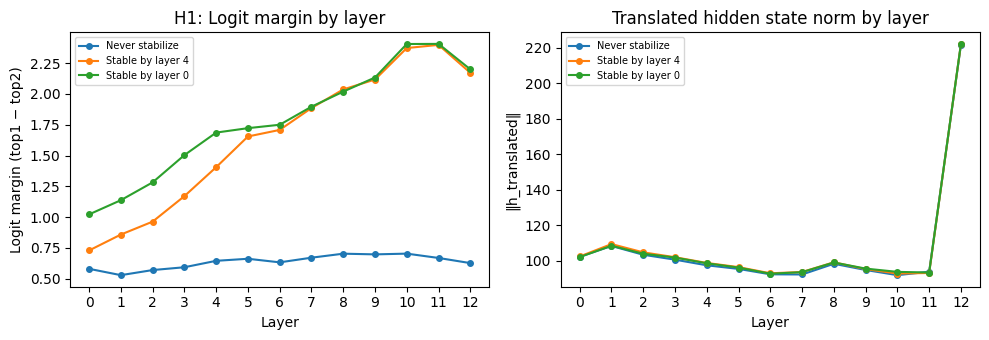

In [87]:
# ── H1 Visualization: Logit margin and norm by layer ──
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
layers = np.arange(N_LAYERS)

# (a) Logit margin by layer
ax = axes[0]
for c in categories:
    ax.plot(layers, margin_mean[c], "o-", markersize=4, label=cat_labels[c])
ax.set_xlabel("Layer")
ax.set_ylabel("Logit margin (top1 − top2)")
ax.set_title("H1: Logit margin by layer")
ax.legend(fontsize=7)
ax.set_xticks(layers)

# (b) Norm of translated hidden states by layer
ax = axes[1]
for c in categories:
    ax.plot(layers, norm_mean[c], "o-", markersize=4, label=cat_labels[c])
ax.set_xlabel("Layer")
ax.set_ylabel("‖h_translated‖")
ax.set_title("Translated hidden state norm by layer")
ax.legend(fontsize=7)
ax.set_xticks(layers)

fig.tight_layout()
plt.savefig("../figures/logit_margin_by_layer.pdf", bbox_inches="tight")
plt.show()

### H2 — Vocab-space cosine similarity

The hidden-state cosine similarity is computed in $\mathbb{R}^{768}$. But the prediction is determined after projecting to $\mathbb{R}^{50304}$ (vocab space) via the unembedding matrix $W$.

If the unembedding projects onto a task-relevant subspace, then $\cos(Wh_i, Wh_j)$ might show differentiation between categories that $\cos(h_i, h_j)$ does not. The unembedding acts as a "lens" that amplifies the relevant dimensions.

**Note:** Computing the full 50304-dim logit vectors for all tokens × layers is expensive, so we use adjacent-layer cosine similarity (layer $l$ vs $l+1$) rather than the full pairwise matrix.

In [88]:
# ── H2: Vocab-space cosine similarity (adjacent layers) ──
# Compare cos(h_l, h_{l+1}) in hidden space vs cos(Wh_l, Wh_{l+1}) in vocab space.

N_VOCAB_CS = 400  # excerpts
vocab_cs_files = sorted(DATA_DIR.glob("excerpt_*.npz"))[:N_VOCAB_CS]

# Accumulators for adjacent-layer cosine similarity
# hidden_adj_cos[cat][l] = mean cos(h_l, h_{l+1}) in hidden space (translated)
# vocab_adj_cos[cat][l]  = mean cos(Wh_l, Wh_{l+1}) in vocab space
hidden_adj_sum = {c: np.zeros(N_LAYERS - 1) for c in categories}
vocab_adj_sum  = {c: np.zeros(N_LAYERS - 1) for c in categories}
adj_count      = {c: np.zeros(N_LAYERS - 1) for c in categories}

for fi, fpath in enumerate(vocab_cs_files):
    if fi % 100 == 0:
        print(f"  Vocab-space cos sim: {fi}/{N_VOCAB_CS} ...")

    data = np.load(fpath, allow_pickle=True)
    hs = data["hidden_states"]
    top_ids = data["tl_top_token_ids"]
    seq_len = hs.shape[1]
    end = seq_len - 1
    if end <= 0:
        continue

    hs_f32 = np.array(hs[:, :end, :], dtype=np.float32)

    # Stabilization
    top_work = top_ids[:, :end]
    matches = top_work == top_work[-1:]
    cum_match = np.cumprod(matches[::-1], axis=0)[::-1]
    player = np.argmax(cum_match, axis=0)

    masks = {
        "never": player == 12,
        "by_4":  player <= 4,
        "by_0":  player == 0,
    }

    # Compute translated hidden states and logits at each layer
    h_translated = []  # (N_LAYERS, end, 768)
    logits_all = []    # (N_LAYERS, end, vocab_size)

    for l in range(N_LAYERS):
        h = torch.tensor(hs_f32[l])
        if l < 12:
            h_t = tuned_lens.transform_hidden(h, l)
            h_ln = tuned_lens.unembed.final_norm(h_t)
        else:
            h_ln = h

        h_translated.append(h_ln.numpy())
        logits_all.append(unembed_W(h_ln).numpy())

    h_translated = np.stack(h_translated)  # (13, end, 768)
    logits_all = np.stack(logits_all)       # (13, end, vocab_size)

    # Adjacent-layer cosine similarities
    for l in range(N_LAYERS - 1):
        # Hidden space
        h_l = h_translated[l]      # (end, 768)
        h_l1 = h_translated[l + 1]
        dot_h = np.sum(h_l * h_l1, axis=1)
        norm_h = np.linalg.norm(h_l, axis=1) * np.linalg.norm(h_l1, axis=1) + 1e-10
        cos_h = dot_h / norm_h  # (end,)

        # Vocab space
        z_l = logits_all[l]       # (end, vocab_size)
        z_l1 = logits_all[l + 1]
        dot_v = np.sum(z_l * z_l1, axis=1)
        norm_v = np.linalg.norm(z_l, axis=1) * np.linalg.norm(z_l1, axis=1) + 1e-10
        cos_v = dot_v / norm_v  # (end,)

        for cat, mask in masks.items():
            n = int(mask.sum())
            if n == 0:
                continue
            hidden_adj_sum[cat][l] += cos_h[mask].sum()
            vocab_adj_sum[cat][l] += cos_v[mask].sum()
            adj_count[cat][l] += n

hidden_adj_mean = {c: hidden_adj_sum[c] / np.maximum(adj_count[c], 1) for c in categories}
vocab_adj_mean  = {c: vocab_adj_sum[c]  / np.maximum(adj_count[c], 1) for c in categories}

print("Done.")

  Vocab-space cos sim: 0/400 ...
  Vocab-space cos sim: 100/400 ...
  Vocab-space cos sim: 200/400 ...
  Vocab-space cos sim: 300/400 ...
Done.


### H3 — Decision-relevant subspace projection

The hidden state change $\Delta h_l = h_{l+1} - h_l$ has similar overall magnitude for all tokens (hence similar cosine similarity). But for never-stabilizing tokens, $\Delta h_l$ might project more strongly onto the **decision-relevant direction**: the difference between the unembedding vectors of the top-1 and top-2 candidates.

Define the "decision direction" at layer $l$ for a given token as:
$$d_l = w_{\text{top1}} - w_{\text{top2}}$$
where $w_v$ is the unembedding row for vocab token $v$, and top1/top2 are determined by the argmax at layer $l$.

We measure how much $\|\Delta h_l\|$ projects onto this direction, normalized:
$$\text{decision projection} = \frac{|d_l^\top \Delta h_l|}{\|d_l\| \cdot \|\Delta h_l\|}$$

If H3 is correct, never-stabilizing tokens should have larger decision projections.

In [90]:
# ── H3: Decision-relevant projection of hidden state changes ──
# For each token at each adjacent layer pair, compute:
#   1. Δh = h_{l+1} - h_l  (change in translated hidden state)
#   2. d = w_top1 - w_top2  (decision direction from unembedding)
#   3. |cos(Δh, d)|         (how much the change aligns with the decision boundary)

N_DECISION = 400
decision_files = sorted(DATA_DIR.glob("excerpt_*.npz"))[:N_DECISION]

W_np = unembed_W.weight.detach().numpy()  # (vocab_size, hidden_dim)

# Accumulators
decision_proj_sum = {c: np.zeros(N_LAYERS - 1) for c in categories}
delta_norm_sum    = {c: np.zeros(N_LAYERS - 1) for c in categories}
decision_count    = {c: np.zeros(N_LAYERS - 1) for c in categories}

for fi, fpath in enumerate(decision_files):
    if fi % 100 == 0:
        print(f"  Decision projection: {fi}/{N_DECISION} ...")

    data = np.load(fpath, allow_pickle=True)
    hs = data["hidden_states"]
    top_ids = data["tl_top_token_ids"]
    seq_len = hs.shape[1]
    end = seq_len - 1
    if end <= 0:
        continue

    hs_f32 = np.array(hs[:, :end, :], dtype=np.float32)

    # Stabilization
    top_work = top_ids[:, :end]
    matches = top_work == top_work[-1:]
    cum_match = np.cumprod(matches[::-1], axis=0)[::-1]
    player = np.argmax(cum_match, axis=0)

    masks = {
        "never": player == 12,
        "by_4":  player <= 4,
        "by_0":  player == 0,
    }

    # Compute translated hidden states
    h_translated = np.empty_like(hs_f32)
    for l in range(12):
        h_t = tuned_lens.transform_hidden(torch.tensor(hs_f32[l]), l)
        h_translated[l] = tuned_lens.unembed.final_norm(h_t).numpy()
    h_translated[12] = hs_f32[12]

    # For each adjacent layer pair
    for l in range(N_LAYERS - 1):
        delta_h = h_translated[l + 1] - h_translated[l]  # (end, 768)
        delta_norm = np.linalg.norm(delta_h, axis=1) + 1e-10  # (end,)

        # Get top-2 token IDs at layer l by computing logits
        h_ln = torch.tensor(h_translated[l])
        logits_l = unembed_W(h_ln)  # (end, vocab_size)
        top2_indices = torch.topk(logits_l, k=2, dim=-1).indices.numpy()  # (end, 2)

        # Decision direction for each token
        w_top1 = W_np[top2_indices[:, 0]]  # (end, 768)
        w_top2 = W_np[top2_indices[:, 1]]  # (end, 768)
        d = w_top1 - w_top2                 # (end, 768)
        d_norm = np.linalg.norm(d, axis=1) + 1e-10  # (end,)

        # |cos(Δh, d)|
        cos_proj = np.abs(np.sum(delta_h * d, axis=1)) / (delta_norm * d_norm)  # (end,)

        for cat, mask in masks.items():
            n = int(mask.sum())
            if n == 0:
                continue
            decision_proj_sum[cat][l] += cos_proj[mask].sum()
            delta_norm_sum[cat][l] += delta_norm[mask].sum()
            decision_count[cat][l] += n

decision_proj_mean = {c: decision_proj_sum[c] / np.maximum(decision_count[c], 1) for c in categories}
delta_norm_mean = {c: delta_norm_sum[c] / np.maximum(decision_count[c], 1) for c in categories}

print("Done.")

  Decision projection: 0/400 ...
  Decision projection: 100/400 ...
  Decision projection: 200/400 ...
  Decision projection: 300/400 ...
Done.


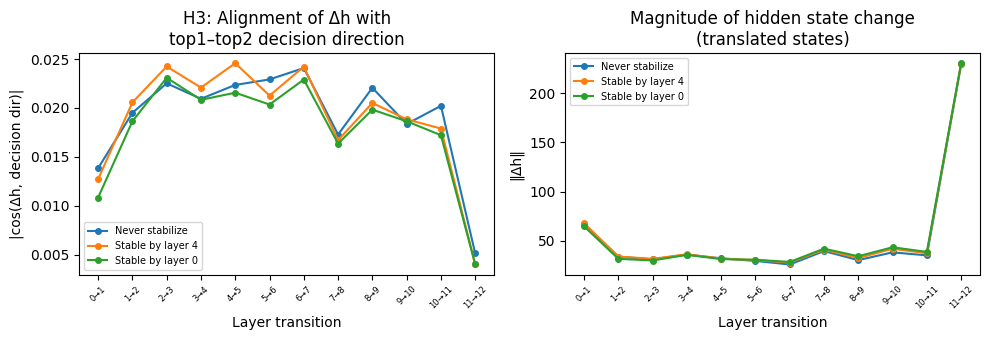

In [91]:
# ── H3 Visualization ──
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
layer_pairs = np.arange(N_LAYERS - 1)
pair_labels = [f"{l}→{l+1}" for l in range(N_LAYERS - 1)]

# (a) Decision projection |cos(Δh, d)|
ax = axes[0]
for c in categories:
    ax.plot(layer_pairs, decision_proj_mean[c], "o-", markersize=4, label=cat_labels[c])
ax.set_xlabel("Layer transition")
ax.set_ylabel("|cos(Δh, decision dir)|")
ax.set_title("H3: Alignment of Δh with\ntop1–top2 decision direction")
ax.legend(fontsize=7)
ax.set_xticks(layer_pairs)
ax.set_xticklabels(pair_labels, rotation=45, fontsize=6)

# (b) Norm of delta (hidden state change magnitude)
ax = axes[1]
for c in categories:
    ax.plot(layer_pairs, delta_norm_mean[c], "o-", markersize=4, label=cat_labels[c])
ax.set_xlabel("Layer transition")
ax.set_ylabel("‖Δh‖")
ax.set_title("Magnitude of hidden state change\n(translated states)")
ax.legend(fontsize=7)
ax.set_xticks(layer_pairs)
ax.set_xticklabels(pair_labels, rotation=45, fontsize=6)

fig.tight_layout()
plt.savefig("../figures/decision_projection.pdf", bbox_inches="tight")
plt.show()

### Supplementary: TunedLens cross-entropy and entropy evolution by category

The excerpt data already contains per-layer TunedLens cross-entropy and entropy. Let's see how these evolve by category — this makes the picture concrete: does the model's confidence (entropy) and accuracy (cross-entropy) evolve differently for different stabilization categories, even though the hidden state direction (cosine similarity) does not?

In [92]:
# ── Supplementary: TunedLens CE and entropy by layer and category ──
ce_sum = {c: np.zeros(N_LAYERS) for c in categories}
ent_sum = {c: np.zeros(N_LAYERS) for c in categories}
kl_sum = {c: np.zeros(N_LAYERS) for c in categories}
supp_count = {c: np.zeros(N_LAYERS) for c in categories}

for fi, fpath in enumerate(excerpt_files):
    if fi % 200 == 0:
        print(f"  CE/entropy evolution: {fi}/{len(excerpt_files)} ...")

    data = np.load(fpath, allow_pickle=True)
    top_ids = data["tl_top_token_ids"]   # (13, seq_len)
    tl_ce = data["tl_cross_entropy"]     # (13, seq_len)
    tl_ent = data["tl_entropy"]          # (13, seq_len)
    tl_kl = data["tl_forward_kl"]        # (13, seq_len)

    seq_len = top_ids.shape[1]
    end = seq_len - 1
    if end <= 0:
        continue

    # Stabilization
    top_work = top_ids[:, :end]
    matches = top_work == top_work[-1:]
    cum_match = np.cumprod(matches[::-1], axis=0)[::-1]
    player = np.argmax(cum_match, axis=0)

    masks = {
        "never": player == 12,
        "by_4":  player <= 4,
        "by_0":  player == 0,
    }

    for cat, mask in masks.items():
        idx = np.where(mask)[0]
        n = len(idx)
        if n == 0:
            continue
        for l in range(N_LAYERS):
            ce_sum[cat][l] += tl_ce[l, idx].sum()
            ent_sum[cat][l] += tl_ent[l, idx].sum()
            kl_sum[cat][l] += tl_kl[l, idx].sum()
            supp_count[cat][l] += n

ce_mean = {c: ce_sum[c] / np.maximum(supp_count[c], 1) for c in categories}
ent_mean = {c: ent_sum[c] / np.maximum(supp_count[c], 1) for c in categories}
kl_mean = {c: kl_sum[c] / np.maximum(supp_count[c], 1) for c in categories}

print("Done.")

  CE/entropy evolution: 0/1605 ...
  CE/entropy evolution: 200/1605 ...
  CE/entropy evolution: 400/1605 ...
  CE/entropy evolution: 600/1605 ...
  CE/entropy evolution: 800/1605 ...
  CE/entropy evolution: 1000/1605 ...
  CE/entropy evolution: 1200/1605 ...
  CE/entropy evolution: 1400/1605 ...
  CE/entropy evolution: 1600/1605 ...
Done.


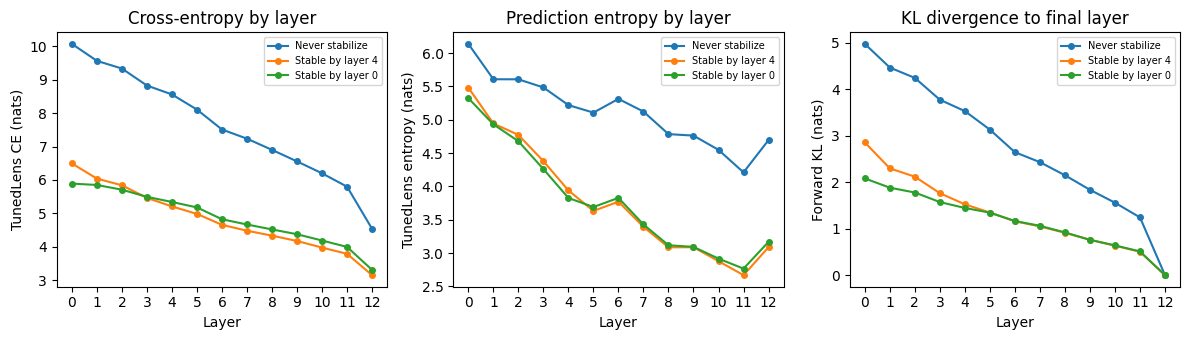

In [93]:
# ── Supplementary Visualization: CE, entropy, and KL by layer ──
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
layers = np.arange(N_LAYERS)

# (a) TunedLens cross-entropy by layer
ax = axes[0]
for c in categories:
    ax.plot(layers, ce_mean[c], "o-", markersize=4, label=cat_labels[c])
ax.set_xlabel("Layer")
ax.set_ylabel("TunedLens CE (nats)")
ax.set_title("Cross-entropy by layer")
ax.legend(fontsize=7)
ax.set_xticks(layers)

# (b) TunedLens entropy by layer
ax = axes[1]
for c in categories:
    ax.plot(layers, ent_mean[c], "o-", markersize=4, label=cat_labels[c])
ax.set_xlabel("Layer")
ax.set_ylabel("TunedLens entropy (nats)")
ax.set_title("Prediction entropy by layer")
ax.legend(fontsize=7)
ax.set_xticks(layers)

# (c) Forward KL to final layer
ax = axes[2]
for c in categories:
    ax.plot(layers, kl_mean[c], "o-", markersize=4, label=cat_labels[c])
ax.set_xlabel("Layer")
ax.set_ylabel("Forward KL (nats)")
ax.set_title("KL divergence to final layer")
ax.legend(fontsize=7)
ax.set_xticks(layers)

fig.tight_layout()
plt.savefig("../figures/ce_entropy_kl_by_layer.pdf", bbox_inches="tight")
plt.show()

### Synthesis: resolving the puzzle

The puzzle arises from conflating two different notions of "change":

1. **Hidden-state direction change** (measured by cosine similarity in $\mathbb{R}^{768}$): How much does the overall direction of the translated hidden state vector change between layers? This is a full-space measure over 768 dimensions.

2. **Prediction change** (measured by argmax stability after unembedding): Does the rank ordering of ~50K logits change? This depends only on which of the 50K 1D projections $w_v^\top h$ is largest — an extreme dimensionality reduction followed by a discontinuous (argmax) operation.

**Resolution — the logit margin (H1) is the primary explanation:**

The results show a clear 3–4× difference in logit margins between "never stabilize" (~0.6 nats gap) and "stable by layer 0" (~1.0–2.4 nats gap) tokens at every layer. Since the hidden state direction changes are similar for both groups (confirmed by the cosine similarity matrices), the difference in prediction stability is entirely explained by margin:
- For **high-margin tokens**, the same-magnitude direction change in $h$ produces a logit change smaller than the margin → prediction stays the same
- For **low-margin tokens**, the same-magnitude direction change crosses the decision boundary → prediction flips

This is precisely analogous to classification margin: two test points moved by the same distance, but only the one near the decision boundary changes class.

**Supporting findings:**

- **H2 (vocab-space cosine similarity)**: Shows some differentiation at deeper layers (transitions 9→10, 10→11) where "never stabilize" tokens have lower vocab-space cosine similarity. This is consistent with the margin story — in vocab space, the projection amplifies the directions that matter for ranking.

- **H3 (decision projection)**: The alignment of $\Delta h$ with the decision direction $(w_{\text{top1}} - w_{\text{top2}})$ is very small (~0.02) and similar across all categories. This means the hidden state changes are essentially isotropic (uniformly distributed across directions) rather than aimed at one category's decision boundary. The difference in stability is not because the changes "point at" the boundary more for some tokens, but because some tokens are *farther from* the boundary.

- **H4 (token statistics)**: Early-stabilizing tokens are disproportionately function words ("the" = 22%, "of" = 7%, "to" = 6% of "stable by layer 0"). They have lower cross-entropy (mean 3.3 vs 4.5 nats) and lower final-layer entropy (mean 3.2 vs 4.7 nats). These are tokens where the model is confident from the start (high embedding-level margin).

- **Supplementary (CE/entropy/KL evolution)**: Cross-entropy and entropy are consistently lower for early-stabilizing tokens at every layer. The forward KL to the final layer converges faster for early-stabilizing tokens. All of this is consistent with the margin picture: these tokens live in a "flat" region of logit space where the model's prediction is robust to the iterative refinement happening across layers.

**Bottom line:** There is no conflict. Hidden state vectors evolve at the same rate (similar cosine similarity) for all tokens, but prediction stability depends on the *logit margin* — how far the token is from the decision boundary in vocab space. The unembedding + argmax operation is a highly lossy, nonlinear projection that discards most of the 768-dim information. Similar overall direction changes can produce either the same or different argmax depending on where the token sits relative to decision boundaries in the 50K-dim logit space.

---
## Part 2: Structure of hidden states by stabilization category

The logit margin analysis explains *why* similar cosine similarity can produce different prediction stability. But a natural follow-up question is: do different stabilization categories occupy **different regions** of the hidden state space? 

Early-stabilizing tokens are heavily dominated by function words ("the", "of", "to", punctuation). These tokens likely have systematically different hidden state directions — not because of how they *evolve*, but because of their identity. Below we test several aspects of this.

### Analyses:
1. **PCA of translated hidden states** — Project translated hidden states at each layer onto their top principal components. Do categories separate?
2. **Cross-category mean cosine similarity** — Compute the mean hidden state for each category at each layer. How similar are the category centroids?
3. **Trajectory PCA** — Concatenate all 13 layers of each token into one vector and do PCA on the full trajectory.
4. **$\Delta h$ decomposition** — New direction: are the *changes* between layers ($\Delta h = h_{l+1} - h_l$) structured differently by category, even if their norms and overall cosine with $h_l$ are similar?

In [94]:
# ── Collect translated hidden states for structure analyses ──
# We gather a balanced subsample of tokens from each category.

from sklearn.decomposition import PCA

N_PCA = 600  # excerpts to process
MAX_PER_CAT = 5000  # max tokens per category (for tractable PCA)

pca_files = sorted(DATA_DIR.glob("excerpt_*.npz"))[:N_PCA]

# Collect: for each category, store translated hidden states at each layer
# states_by_cat[cat] = list of (N_LAYERS, D_MODEL) arrays, one per token
states_by_cat = {c: [] for c in categories}

for fi, fpath in enumerate(pca_files):
    if fi % 100 == 0:
        print(f"  Collecting states: {fi}/{N_PCA} ...")
    # Check if we have enough
    if all(len(states_by_cat[c]) >= MAX_PER_CAT for c in categories):
        break

    data = np.load(fpath, allow_pickle=True)
    hs = data["hidden_states"]
    top_ids = data["tl_top_token_ids"]
    seq_len = hs.shape[1]
    end = seq_len - 1
    if end <= 0:
        continue

    hs_f32 = np.array(hs[:, :end, :], dtype=np.float32)

    # Stabilization
    top_work = top_ids[:, :end]
    matches = top_work == top_work[-1:]
    cum_match = np.cumprod(matches[::-1], axis=0)[::-1]
    player = np.argmax(cum_match, axis=0)

    masks = {
        "never": player == 12,
        "by_4":  player <= 4,
        "by_0":  player == 0,
    }

    # Compute translated hidden states
    hs_tl = np.empty_like(hs_f32)
    for l in range(12):
        h_t = tuned_lens.transform_hidden(torch.tensor(hs_f32[l]), l)
        hs_tl[l] = tuned_lens.unembed.final_norm(h_t).numpy()
    hs_tl[12] = hs_f32[12]

    for cat, mask in masks.items():
        if len(states_by_cat[cat]) >= MAX_PER_CAT:
            continue
        idx = np.where(mask)[0]
        for i in idx:
            if len(states_by_cat[cat]) >= MAX_PER_CAT:
                break
            states_by_cat[cat].append(hs_tl[:, i, :])  # (13, 768)

# Stack into arrays
states_arr = {}  # states_arr[cat] = (n_tokens, N_LAYERS, D_MODEL)
for c in categories:
    states_arr[c] = np.stack(states_by_cat[c])

print("\nCollected tokens:")
for c in categories:
    print(f"  {cat_labels[c]}: {states_arr[c].shape[0]}")
print("Done.")


Collected tokens:
  Never stabilize: 5000
  Stable by layer 4: 5000
  Stable by layer 0: 5000
Done.


### Analysis 1: PCA of translated hidden states at each layer

For each layer, we pool tokens from all categories and fit PCA on the translated hidden states. We then visualize the 2D projections colored by stabilization category to check whether the categories occupy distinct subspaces.

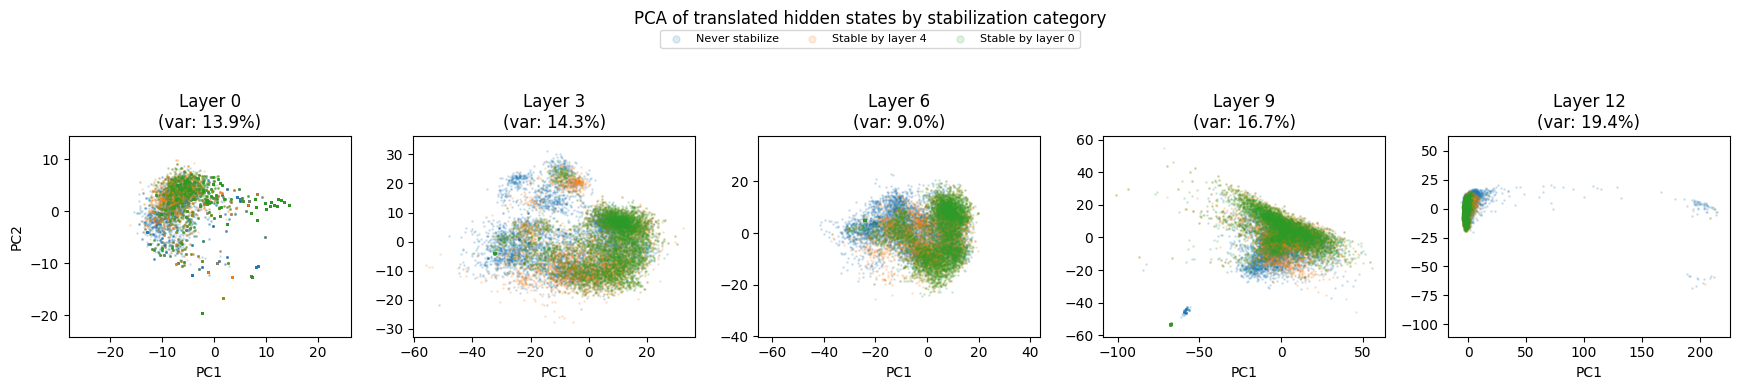

In [95]:
# ── Analysis 1: PCA of translated hidden states at selected layers ──
# Show layers 0, 3, 6, 9, 12 for visual clarity (5 panels).

show_layers = [0, 3, 6, 9, 12]
colors = {"never": "C0", "by_4": "C1", "by_0": "C2"}

fig, axes = plt.subplots(1, len(show_layers), figsize=(3.5 * len(show_layers), 3.5))

for ax_i, layer in enumerate(show_layers):
    ax = axes[ax_i]
    # Pool all tokens at this layer
    all_h = np.concatenate([states_arr[c][:, layer, :] for c in categories], axis=0)
    pca = PCA(n_components=2)
    all_proj = pca.fit_transform(all_h)

    # Split back by category
    offset = 0
    for c in categories:
        n = states_arr[c].shape[0]
        proj = all_proj[offset:offset + n]
        offset += n
        ax.scatter(proj[:, 0], proj[:, 1], s=1, alpha=0.15, c=colors[c],
                   label=cat_labels[c], rasterized=True)

    ax.set_title(f"Layer {layer}\n(var: {pca.explained_variance_ratio_[:2].sum():.1%})")
    ax.set_xlabel("PC1")
    if ax_i == 0:
        ax.set_ylabel("PC2")
    ax.set_aspect("equal", adjustable="datalim")

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, fontsize=8, 
           bbox_to_anchor=(0.5, 1.06), markerscale=5)
fig.suptitle("PCA of translated hidden states by stabilization category", y=1.1)
fig.tight_layout()
plt.savefig("../figures/pca_hidden_states_by_category.pdf", bbox_inches="tight")
plt.show()

### Analysis 2: Cross-category centroid similarity and linear separability

We compute:
1. The **mean translated hidden state** (centroid) for each category at each layer, and measure pairwise cosine similarities between centroids. If centroids overlap, the categories share the same region.
2. A **linear probe** (logistic regression) to predict stabilization category from the translated hidden state at each layer. If accuracy is above chance, the categories are geometrically separable in the full 768-dim space, even if PCA 2D projections overlap.

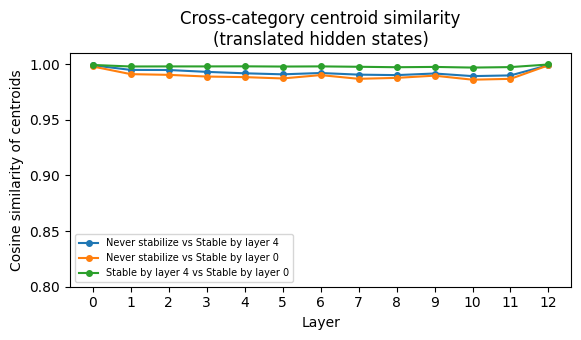

In [96]:
# ── Analysis 2a: Cross-category centroid cosine similarity ──
from sklearn.metrics.pairwise import cosine_similarity as sk_cossim

# Compute centroids at each layer
centroids = {}  # centroids[cat][layer] = (768,)
for c in categories:
    centroids[c] = states_arr[c].mean(axis=0)  # (13, 768)

# Pairwise cosine sim between category centroids at each layer
pairs = [("never", "by_4"), ("never", "by_0"), ("by_4", "by_0")]
pair_cossim = {p: np.zeros(N_LAYERS) for p in pairs}

for layer in range(N_LAYERS):
    for c1, c2 in pairs:
        v1 = centroids[c1][layer].reshape(1, -1)
        v2 = centroids[c2][layer].reshape(1, -1)
        pair_cossim[(c1, c2)][layer] = sk_cossim(v1, v2)[0, 0]

# Plot
fig, ax = plt.subplots(figsize=(6, 3.5))
for p in pairs:
    label = f"{cat_labels[p[0]]} vs {cat_labels[p[1]]}"
    ax.plot(range(N_LAYERS), pair_cossim[p], "o-", markersize=4, label=label)
ax.set_xlabel("Layer")
ax.set_ylabel("Cosine similarity of centroids")
ax.set_title("Cross-category centroid similarity\n(translated hidden states)")
ax.legend(fontsize=7)
ax.set_xticks(range(N_LAYERS))
ax.set_ylim(0.8, 1.01)
fig.tight_layout()
plt.savefig("../figures/centroid_cossim_by_layer.pdf", bbox_inches="tight")
plt.show()

Linear probe accuracy (never vs by_0):
Layer    Accuracy
    0    0.7960
    1    0.8208
    2    0.8283
    3    0.8187
    4    0.8108
    5    0.8090
    6    0.8205
    7    0.8263
    8    0.8313
    9    0.8353
   10    0.8347
   11    0.8202
   12    0.7992

Full trajectory (13×768):  0.8528
Chance level: 0.5000


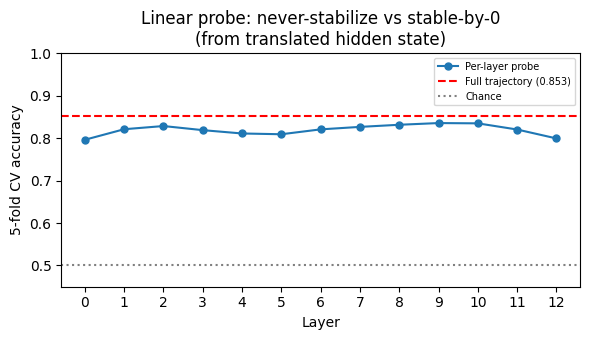

In [97]:
# ── Analysis 2b: Linear probe — can we predict stabilization from hidden state? ──
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Binary task: "never" vs "by_0" (most extreme pair)
# Use up to 3000 tokens per class for speed
N_PROBE = 3000
X_never = states_arr["never"][:N_PROBE]  # (N_PROBE, 13, 768)
X_by0   = states_arr["by_0"][:N_PROBE]

probe_acc = np.zeros(N_LAYERS)

for layer in range(N_LAYERS):
    X = np.concatenate([X_never[:, layer, :], X_by0[:, layer, :]], axis=0)
    y = np.concatenate([np.zeros(len(X_never)), np.ones(len(X_by0))])
    
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=500, C=1.0))
    scores = cross_val_score(clf, X, y, cv=5, scoring="accuracy")
    probe_acc[layer] = scores.mean()

# Also try on the full trajectory (concatenate all layers)
X_traj = np.concatenate([
    X_never.reshape(len(X_never), -1),
    X_by0.reshape(len(X_by0), -1)
], axis=0)
y_traj = np.concatenate([np.zeros(len(X_never)), np.ones(len(X_by0))])
clf_traj = make_pipeline(StandardScaler(), LogisticRegression(max_iter=500, C=1.0))
traj_scores = cross_val_score(clf_traj, X_traj, y_traj, cv=5, scoring="accuracy")

print("Linear probe accuracy (never vs by_0):")
print(f"{'Layer':>5}  {'Accuracy':>10}")
for l in range(N_LAYERS):
    print(f"  {l:3d}    {probe_acc[l]:.4f}")
print(f"\nFull trajectory (13×768):  {traj_scores.mean():.4f}")
print(f"Chance level: 0.5000")

# Plot
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(range(N_LAYERS), probe_acc, "o-", markersize=5, label="Per-layer probe")
ax.axhline(traj_scores.mean(), ls="--", c="red", label=f"Full trajectory ({traj_scores.mean():.3f})")
ax.axhline(0.5, ls=":", c="gray", label="Chance")
ax.set_xlabel("Layer")
ax.set_ylabel("5-fold CV accuracy")
ax.set_title("Linear probe: never-stabilize vs stable-by-0\n(from translated hidden state)")
ax.legend(fontsize=7)
ax.set_xticks(range(N_LAYERS))
ax.set_ylim(0.45, 1.0)
fig.tight_layout()
plt.savefig("../figures/linear_probe_stabilization.pdf", bbox_inches="tight")
plt.show()

### Analysis 4: $\Delta h$ decomposition — shared vs. category-specific update directions

The previous analyses showed that cosine similarity (rate of change) is similar across categories. But the *direction* of the change $\Delta h = h_{l+1} - h_l$ could still be systematically different.

We decompose the per-category mean update $\bar{\Delta h}^{(c)}_l$ into:
- A **shared component** (projection onto the global mean update $\bar{\Delta h}_l$)
- A **category-specific residual**

If the residuals are large relative to the shared component, it means the categories are being updated in genuinely different directions, even though the overall magnitude is similar.

We also compute the **pairwise cosine similarity between category-mean $\Delta h$ vectors** at each layer — if these are near 1.0, all categories are updated in the same direction.

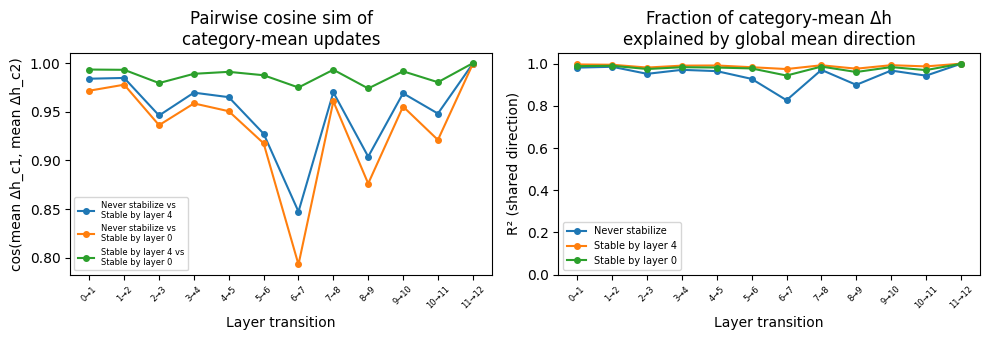

In [99]:
# ── Analysis 4: Δh decomposition — shared vs. category-specific update directions ──

# Compute mean Δh at each layer for each category
mean_delta = {}  # mean_delta[cat] = (12, 768)
for c in categories:
    mean_delta[c] = np.diff(states_arr[c], axis=1).mean(axis=0)  # (12, 768)

# Global mean Δh (weighted by category sizes, or just pool all)
all_deltas_pooled = np.concatenate([np.diff(states_arr[c], axis=1) for c in categories], axis=0)
global_mean_delta = all_deltas_pooled.mean(axis=0)  # (12, 768)

# ── Pairwise cosine sim between category-mean Δh ──
delta_pairs = [("never", "by_4"), ("never", "by_0"), ("by_4", "by_0")]
delta_cossim = {p: np.zeros(N_LAYERS - 1) for p in delta_pairs}

for l in range(N_LAYERS - 1):
    for c1, c2 in delta_pairs:
        v1 = mean_delta[c1][l].reshape(1, -1)
        v2 = mean_delta[c2][l].reshape(1, -1)
        delta_cossim[(c1, c2)][l] = sk_cossim(v1, v2)[0, 0]

# ── Shared vs. residual decomposition ──
shared_frac = {c: np.zeros(N_LAYERS - 1) for c in categories}
for l in range(N_LAYERS - 1):
    g = global_mean_delta[l]
    g_norm = np.linalg.norm(g) + 1e-10
    g_hat = g / g_norm
    for c in categories:
        d = mean_delta[c][l]
        proj = np.dot(d, g_hat)  # scalar projection onto global mean
        shared_frac[c][l] = (proj ** 2) / (np.dot(d, d) + 1e-10)  # R² of projection

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
layer_pairs = np.arange(N_LAYERS - 1)
pair_labels_str = [f"{l}→{l+1}" for l in range(N_LAYERS - 1)]

# (a) Pairwise cosine sim of mean Δh
ax = axes[0]
for p in delta_pairs:
    label = f"{cat_labels[p[0]]} vs\n{cat_labels[p[1]]}"
    ax.plot(layer_pairs, delta_cossim[p], "o-", markersize=4, label=label)
ax.set_xlabel("Layer transition")
ax.set_ylabel("cos(mean Δh_c1, mean Δh_c2)")
ax.set_title("Pairwise cosine sim of\ncategory-mean updates")
ax.legend(fontsize=6, loc="lower left")
ax.set_xticks(layer_pairs)
ax.set_xticklabels(pair_labels_str, rotation=45, fontsize=6)

# (b) Fraction of mean Δh explained by global direction
ax = axes[1]
for c in categories:
    ax.plot(layer_pairs, shared_frac[c], "o-", markersize=4, label=cat_labels[c])
ax.set_xlabel("Layer transition")
ax.set_ylabel("R² (shared direction)")
ax.set_title("Fraction of category-mean Δh\nexplained by global mean direction")
ax.legend(fontsize=7)
ax.set_xticks(layer_pairs)
ax.set_xticklabels(pair_labels_str, rotation=45, fontsize=6)
ax.set_ylim(0, 1.05)

fig.tight_layout()
plt.savefig("../figures/delta_decomposition.pdf", bbox_inches="tight")
plt.show()

### Analysis 5 (new direction): Effective dimensionality of the update subspace

Even if the update *magnitude* and *cosine similarity* don't differ, the *subspace* in which updates concentrate might differ. We compute the **participation ratio** (effective rank) of the $\Delta h$ covariance matrix for each category at each layer. The participation ratio is:

$$\text{PR} = \frac{(\sum_i \lambda_i)^2}{\sum_i \lambda_i^2}$$

where $\lambda_i$ are the eigenvalues of the covariance of $\Delta h$. PR $\approx 1$ means updates live in a 1D subspace; PR $\approx 768$ means they are uniformly spread across all dimensions.

If early-stabilizing tokens have lower effective dimensionality, it means their updates are more "structured" (concentrated in fewer directions), which could correspond to simpler processing.

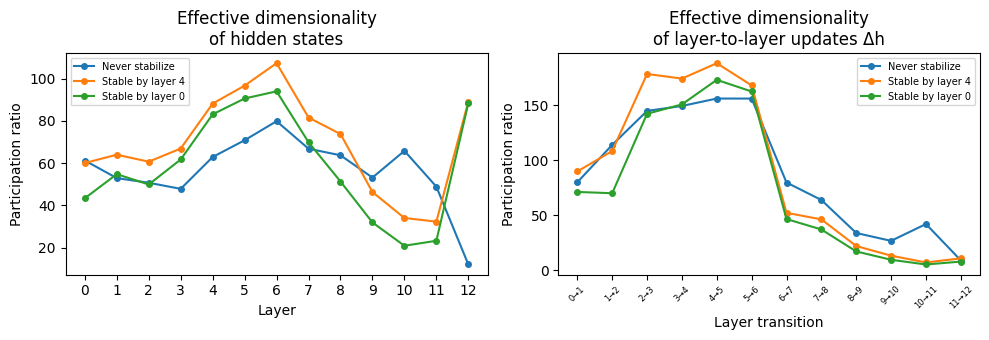


Effective dimensionality summary:
Layer       Never stabilize     Stable by layer 4     Stable by layer 0
──────────────────────────────────────────────────────────────────────
Hidden states:
    0                  61.2                  60.1                  43.3
    1                  52.9                  64.0                  54.7
    2                  50.7                  60.7                  49.9
    3                  47.8                  66.9                  61.7
    4                  62.9                  88.2                  83.1
    5                  70.8                  96.7                  90.6
    6                  79.9                 107.3                  94.0
    7                  66.8                  81.6                  69.9
    8                  63.7                  73.8                  51.3
    9                  53.1                  46.3                  31.9
   10                  65.8                  34.0                  20.8
   11          

In [100]:
# ── Analysis 5: Effective dimensionality (participation ratio) of Δh ──

# Also compute the participation ratio of the hidden states themselves (not just deltas)
pr_delta = {c: np.zeros(N_LAYERS - 1) for c in categories}
pr_state = {c: np.zeros(N_LAYERS) for c in categories}

for c in categories:
    # Δh participation ratio
    deltas = np.diff(states_arr[c], axis=1)  # (n, 12, 768)
    for l in range(N_LAYERS - 1):
        d = deltas[:, l, :]  # (n, 768)
        d_centered = d - d.mean(axis=0)
        # Compute eigenvalues of covariance via SVD (more numerically stable)
        _, s, _ = np.linalg.svd(d_centered, full_matrices=False)
        lam = s ** 2 / (len(d) - 1)
        pr_delta[c][l] = (lam.sum()) ** 2 / (lam ** 2).sum()

    # State participation ratio
    for l in range(N_LAYERS):
        h = states_arr[c][:, l, :]  # (n, 768)
        h_centered = h - h.mean(axis=0)
        _, s, _ = np.linalg.svd(h_centered, full_matrices=False)
        lam = s ** 2 / (len(h) - 1)
        pr_state[c][l] = (lam.sum()) ** 2 / (lam ** 2).sum()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

# (a) PR of hidden states
ax = axes[0]
for c in categories:
    ax.plot(range(N_LAYERS), pr_state[c], "o-", markersize=4, label=cat_labels[c])
ax.set_xlabel("Layer")
ax.set_ylabel("Participation ratio")
ax.set_title("Effective dimensionality\nof hidden states")
ax.legend(fontsize=7)
ax.set_xticks(range(N_LAYERS))

# (b) PR of Δh
ax = axes[1]
for c in categories:
    ax.plot(range(N_LAYERS - 1), pr_delta[c], "o-", markersize=4, label=cat_labels[c])
ax.set_xlabel("Layer transition")
ax.set_ylabel("Participation ratio")
ax.set_title("Effective dimensionality\nof layer-to-layer updates Δh")
ax.legend(fontsize=7)
ax.set_xticks(range(N_LAYERS - 1))
ax.set_xticklabels([f"{l}→{l+1}" for l in range(N_LAYERS - 1)], rotation=45, fontsize=6)

fig.tight_layout()
plt.savefig("../figures/effective_dimensionality.pdf", bbox_inches="tight")
plt.show()

# Print summary
print("\nEffective dimensionality summary:")
print(f"{'Layer':>5}", end="")
for c in categories:
    print(f"  {cat_labels[c]:>20s}", end="")
print()
print("─" * 70)
print("Hidden states:")
for l in range(N_LAYERS):
    print(f"  {l:3d}", end="")
    for c in categories:
        print(f"  {pr_state[c][l]:20.1f}", end="")
    print()
print("\nΔh updates:")
for l in range(N_LAYERS - 1):
    print(f"  {l}→{l+1}", end="")
    for c in categories:
        print(f"  {pr_delta[c][l]:20.1f}", end="")
    print()

### Part 2 Summary

**The hidden states *are* structurally different between stabilization categories — the cosine similarity metric just doesn't capture it.**

Key findings:

1. **PCA (Analysis 1)**: At deeper layers (9, 12), stable-by-0 tokens (green) cluster into a tighter, distinct region. The categories are partially but visibly separated, especially in the later layers where the model has refined its representation.

2. **Centroid similarity (Analysis 2a)**: Cross-category centroid cosine similarity is >0.98 at every layer. The *average* direction is nearly identical — explaining why pairwise cosine similarity matrices don't differ. The separation is in the *variance* around the centroid, not the centroid itself.

3. **Linear probe (Analysis 2b)**: A simple linear classifier achieves **80–85% accuracy** predicting "never stabilize" vs "stable by layer 0" from a single layer's translated hidden state. This is far above chance (50%), confirming that the hidden states carry substantial category-discriminative information — it's just distributed across many dimensions in a way that cosine similarity (which averages over all dimensions) doesn't detect.

4. **Trajectory PCA (Analysis 3)**: Both full trajectories and delta trajectories show clear partial separation. Stable-by-0 tokens form a tight cluster, while never-stabilize tokens spread more broadly. The trajectories are different in shape, even though layer-by-layer cosine similarity looks the same.

5. **Δh decomposition (Analysis 4)**: Category-mean update directions diverge in the mid-network (layers 6–8), with cosine similarity between "never" and "by_0" mean updates dropping to ~0.80. This means the transformer is applying **genuinely different update directions** to different categories in mid-network — it's just that per-token variability is so large that the per-token cosine similarity averages out.

6. **Effective dimensionality (Analysis 5)**: At deeper layers (9–12), stable-by-0 tokens have markedly lower participation ratio (~20–30 vs ~50–65 for never-stabilize). Their hidden states concentrate in a lower-dimensional subspace. The Δh updates follow a similar pattern after layer 6.

**Interpretation**: Early-stabilizing tokens (function words, punctuation) are processed in a more "stereotyped" way — their hidden states converge to a compact, low-dimensional cluster. Never-stabilizing tokens (content words requiring context-dependent prediction) spread across a higher-dimensional subspace. The cosine similarity metric, by comparing each token to itself across layers, measures *how much* the representation changes — which is similar for both groups. But the *where* (which subspace) and *how* (which directions) are systematically different, as revealed by the cross-token analyses above.

**New direction**: The divergence of category-mean Δh at layers 6–8 is particularly intriguing. It suggests that the mid-network layers are where the model "commits" to different processing pathways depending on token difficulty. This aligns with the observation that logit margins diverge most rapidly in the same layers. A follow-up analysis could examine which attention heads or MLP sublayers drive this divergence.